In [14]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display 
import matplotlib.pyplot as plt

In [15]:
# Gizli Sayı 
secret_number = '10101010100'
n = len(secret_number) # Kübit sayısı (11)

In [16]:
# n giriş kübiti + 1 hedef kübiti)
circuit = QuantumCircuit(n + 1, n)

In [17]:
circuit.h(range(n)) # Girişlere Hadamard

# Hedef kübiti |-> durumuna getir (X sonra H)
circuit.x(n)
circuit.h(n)

circuit.barrier()

print(f"Gizli Sayı ({secret_number}) devreye işleniyor...")

Gizli Sayı (10101010100) devreye işleniyor...


In [18]:
# 'reversed' kullanıyoruz çünkü Qiskit bitleri sağdan sola (0. indeks en sağ) dizer.
# Bu sayede ölçüm sonucu string ile birebir aynı çıkar.
for index, bit in enumerate(reversed(secret_number)):
    if bit == "1":
        circuit.cx(index, n)

circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=12, num_clbits=0, params=[]), qubits=(<Qubit register=(12, "q"), index=0>, <Qubit register=(12, "q"), index=1>, <Qubit register=(12, "q"), index=2>, <Qubit register=(12, "q"), index=3>, <Qubit register=(12, "q"), index=4>, <Qubit register=(12, "q"), index=5>, <Qubit register=(12, "q"), index=6>, <Qubit register=(12, "q"), index=7>, <Qubit register=(12, "q"), index=8>, <Qubit register=(12, "q"), index=9>, <Qubit register=(12, "q"), index=10>, <Qubit register=(12, "q"), index=11>), clbits=())

In [19]:
# Geri Dönüşüm
circuit.h(range(n))
circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=12, num_clbits=0, params=[]), qubits=(<Qubit register=(12, "q"), index=0>, <Qubit register=(12, "q"), index=1>, <Qubit register=(12, "q"), index=2>, <Qubit register=(12, "q"), index=3>, <Qubit register=(12, "q"), index=4>, <Qubit register=(12, "q"), index=5>, <Qubit register=(12, "q"), index=6>, <Qubit register=(12, "q"), index=7>, <Qubit register=(12, "q"), index=8>, <Qubit register=(12, "q"), index=9>, <Qubit register=(12, "q"), index=10>, <Qubit register=(12, "q"), index=11>), clbits=())

In [20]:
circuit.measure(range(n), range(n))

Devre Şeması:


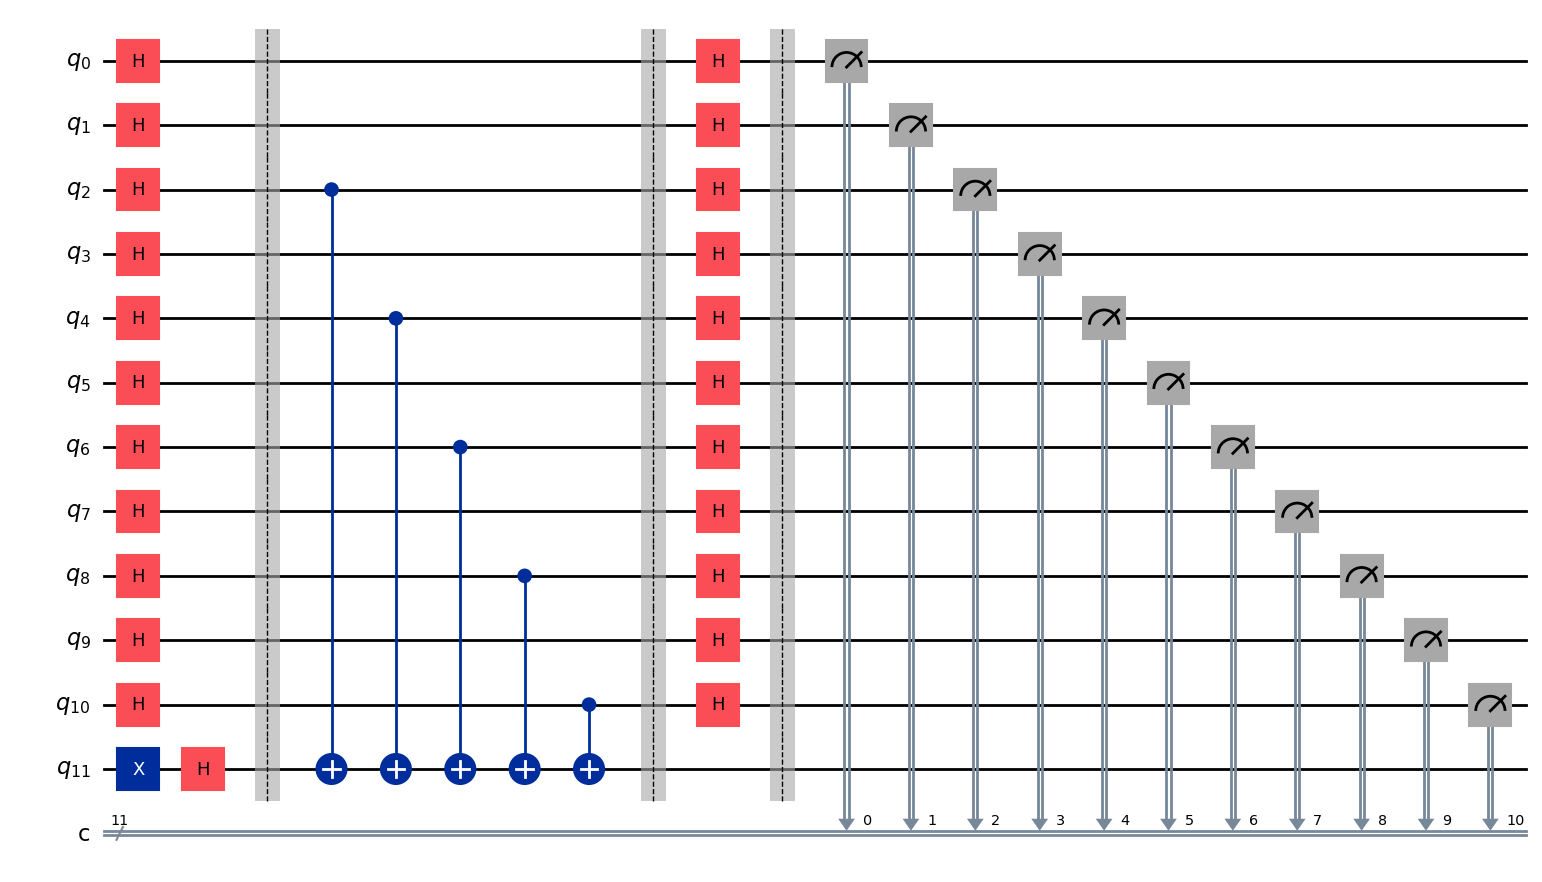

In [21]:
print("Devre Şeması:")
display(circuit.draw(output='mpl', fold=-1)) # fold=-1 devreyi tek satıra sığdırır

In [22]:
simulator = AerSimulator()
t_circuit = transpile(circuit, simulator)

In [23]:
# Tek atış (shots=1) yeterli
result = simulator.run(t_circuit, shots=1).result()
counts = result.get_counts()

print("\nBulunan Sonuç:", counts)


Bulunan Sonuç: {'10101010100': 1}


In [24]:
if list(counts.keys())[0] == secret_number:
    print("✅ BAŞARILI! Kuantum bilgisayar gizli sayıyı tek seferde buldu.")
else:
    print("❌ HATA: Sayı eşleşmedi.")

✅ BAŞARILI! Kuantum bilgisayar gizli sayıyı tek seferde buldu.


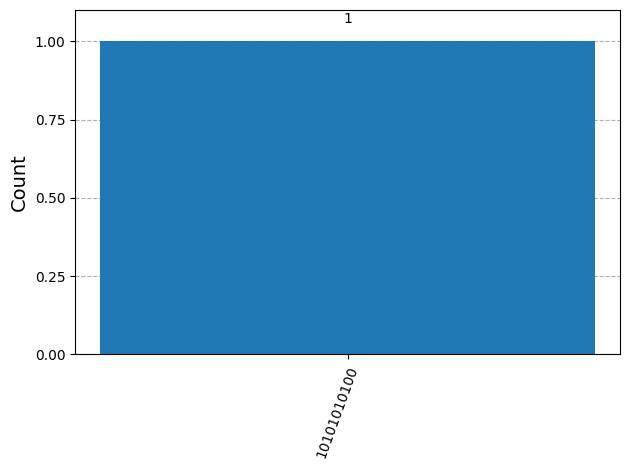

In [25]:
display(plot_histogram(counts))